# E2.0 — Start-Frame Extractor

Generates diverse starting conformations for the extended-production replicates (E2.1). Rather
than reseeding velocities on a single frame 0 — which gives no conformational diversity — this
samples genuinely different points along the slow compact↔extended axis from the system's
longest trajectory (the 100 ns diagnostic, or the 200 ns extended_r1 for systems without one),
so each replicate launches from a different region of conformational
space. That is what lets the extended-start and compact-start ensembles serve as an ergodicity
test: if they converge to the same SASA/Rg distribution, sampling is adequate; if they don't,
the trajectories are trapped.

**Method.** Compute the peptide radius of gyration per frame across that source trajectory,
discard the equilibration window, and select the frames nearest chosen Rg percentiles (default
10th / 50th / 90th → compact / mid / extended). Each selected full-system frame (peptide +
solvent + DES) is written as a PDB starting structure. The selection is deterministic and the
PDBs are small (~hundreds of kB), so they are committable — making the convergence test
reproducible from git even though the trajectories themselves are not.

**Output.** `extension/start_frames/{system}/{system}_{label}.pdb`, a selection-record CSV, and
ready-to-paste E2.1 configuration blocks for each diverse-start replicate.

## 1 — Imports
**Out:** namespace.

In [2]:
import re, json
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt

print(f"MDTraj {md.__version__}")

MDTraj 1.11.1


## 2 — Configuration
`SELECTIONS` are (label, Rg-percentile) pairs. The label becomes the E2.1 `START` tag and the
PDB filename. **Out:** parameters.

In [3]:
SYSTEM = "YIY_reline"
EQUIL_DISCARD_NS = 20.0                       # scaled to glyceline tau_int
SELECTIONS       = [("compact", 10), ("mid", 50), ("open", 90)]
NS_TARGET        = 200                        # for the printed E2.1 configs
SAVE_INTERVAL_PS = 1.0                        # diagnostic DCD frame spacing

THREE_TO_ONE = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E',
                'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
                'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}

## 3 — Resolve paths and load the source trajectory
Loads the source — the 100 ns diagnostic if the system has one, otherwise its 200 ns extended_r1
run (the bootstrap path for reline and YIY_glyceline) — and isolates the peptide. The 200 ns
source is ~7 GB in memory, comfortable here. **Out:** `traj`, `prot`, `motif_idx`, `PRMTOP`.

In [4]:
PROJECT_DIR = Path("~/des-peptide-study").expanduser()
SYSTEMS_DIR = PROJECT_DIR / "systems"
TRAJ_DIR    = PROJECT_DIR / "extension" / "trajectories"
EXT_DIR     = PROJECT_DIR / "extension" / "trajectories_extended"

def resolve(name):
    for cand in (SYSTEMS_DIR / SYSTEM / name, SYSTEMS_DIR / name):
        if cand.exists():
            return cand
    raise FileNotFoundError(f"{name} not found for {SYSTEM}")

PRMTOP = resolve(f"{SYSTEM}.prmtop")

# Source: 100 ns diagnostic if the system has one, else its 200 ns extended_r1 run
# (the bootstrap path for systems with no diagnostic -- reline trio, YIY_glyceline).
diag = TRAJ_DIR / f"{SYSTEM}_rep1" / f"{SYSTEM}_rep1.dcd"
ext  = EXT_DIR / f"{SYSTEM}_200ns_extended_r1" / f"{SYSTEM}_200ns_extended_r1.dcd"
if diag.exists():
    SOURCE_DCD, source_kind = diag, "100 ns diagnostic"
elif ext.exists():
    SOURCE_DCD, source_kind = ext, "200 ns extended_r1 (bootstrap)"
else:
    raise FileNotFoundError(f"no diagnostic or extended_r1 trajectory for {SYSTEM}")

print(f"source: {SOURCE_DCD.name}  [{source_kind}]")
traj = md.load(str(SOURCE_DCD), top=str(PRMTOP))
print(f"  {traj.n_frames} frames, {traj.n_atoms} atoms")

prot_sel = traj.topology.select("protein")
if len(prot_sel) == 0:
    prot_sel = traj.topology.select("not (water or resname HOH WAT CHO CLA URE GOL NA CL Na+ Cl-)")
prot = traj.atom_slice(prot_sel)

motif_seq = SYSTEM.split("_")[0]
seq = "".join(THREE_TO_ONE.get(r.name, "X") for r in prot.topology.residues)
pos = seq.find(motif_seq)
assert pos >= 0, f"motif {motif_seq} not found in {seq}"
motif_idx = list(range(pos, pos + len(motif_seq)))
print(f"  peptide sequence {seq}; motif {motif_seq} at residues {motif_idx}")

source: YIY_reline_200ns_extended_r1.dcd  [200 ns extended_r1 (bootstrap)]
  200000 frames, 2849 atoms
  peptide sequence XNPYIYKX; motif YIY at residues [3, 4, 5]


## 4 — Radius of gyration and equilibration discard
Rg is cheap to compute across all frames. **Out:** `rg_eq`, `t_eq`, plus context on where the
already-run extended start (frame 0) sits in the distribution.

In [5]:
dt_ps   = SAVE_INTERVAL_PS
n_equil = int(EQUIL_DISCARD_NS * 1000.0 / dt_ps)

rg_all = md.compute_rg(prot)                       # nm, all frames
rg_eq  = rg_all[n_equil:]
t_eq   = (np.arange(len(rg_eq)) + n_equil) * dt_ps / 1000.0   # ns

frame0_rg  = rg_all[0]
frame0_pct = (rg_eq < frame0_rg).mean() * 100
print(f"Rg over equilibrated window ({EQUIL_DISCARD_NS:g}-{t_eq[-1]:.0f} ns):")
print(f"  min {rg_eq.min():.3f}  median {np.median(rg_eq):.3f}  max {rg_eq.max():.3f} nm")
print(f"frame 0 (extended-start r1 already run): Rg {frame0_rg:.3f} nm "
      f"= {frame0_pct:.0f}th percentile of the equilibrated range")

Rg over equilibrated window (20-200 ns):
  min 0.559  median 0.686  max 0.812 nm
frame 0 (extended-start r1 already run): Rg 0.703 nm = 62th percentile of the equilibrated range


## 5 — Select diverse frames
For each target percentile, pick the equilibrated frame whose Rg is closest. Motif SASA at each
pick is reported for context (computed on just the selected frames). **Out:** `picks` table.

In [6]:
sel_local = {}
for label, pct in SELECTIONS:
    target = np.percentile(rg_eq, pct)
    i_local = int(np.argmin(np.abs(rg_eq - target)))
    sel_local[label] = i_local + n_equil      # global frame index

sel_global = [sel_local[l] for l, _ in SELECTIONS]
picks_traj = traj[sel_global]
sasa_pick = md.shrake_rupley(picks_traj.atom_slice(prot_sel), mode="residue")[:, motif_idx].sum(axis=1)

rows = []
for (label, pct), gidx, sasa in zip(SELECTIONS, sel_global, sasa_pick):
    rows.append({"label": label, "target_pct": pct, "frame": gidx,
                 "time_ns": round(gidx * dt_ps / 1000.0, 1),
                 "Rg_nm": round(float(rg_all[gidx]), 3),
                 "motif_SASA_nm2": round(float(sasa), 3)})
picks = pd.DataFrame(rows)
print(picks.to_string(index=False))

  label  target_pct  frame  time_ns  Rg_nm  motif_SASA_nm2
compact          10  76568     76.6  0.618           5.226
    mid          50  80599     80.6  0.686           5.183
   open          90 132775    132.8  0.736           5.659


## 6 — Save starting structures and verify round-trip
Each full-system frame is written as a PDB, then reloaded with the topology to confirm the Rg is
preserved — the same load path E2.1 uses, so a passing check here means E2.1 will read them
correctly. **Out:** PDBs + `start_frames.csv`.

In [7]:
OUT_DIR = PROJECT_DIR / "extension" / "start_frames" / SYSTEM
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {}
for label, gidx in zip([l for l, _ in SELECTIONS], sel_global):
    pdb_path = OUT_DIR / f"{SYSTEM}_{label}.pdb"
    traj[gidx].save_pdb(str(pdb_path))
    reloaded = md.load(str(pdb_path), top=str(PRMTOP))
    rg_reload = float(md.compute_rg(reloaded.atom_slice(reloaded.topology.select("protein")))[0])
    ok = abs(rg_reload - rg_all[gidx]) < 0.01
    paths[label] = pdb_path
    print(f"  {label:<9} -> {pdb_path.name}  Rg saved {rg_all[gidx]:.3f} / reloaded "
          f"{rg_reload:.3f} nm  {'OK' if ok else 'MISMATCH'}")

picks["pdb_path"] = [str(paths[l]) for l in picks["label"]]
picks.to_csv(OUT_DIR / "start_frames.csv", index=False)
print("\nselection record:", OUT_DIR / "start_frames.csv")

  compact   -> YIY_reline_compact.pdb  Rg saved 0.618 / reloaded 0.618 nm  OK
  mid       -> YIY_reline_mid.pdb  Rg saved 0.686 / reloaded 0.686 nm  OK
  open      -> YIY_reline_open.pdb  Rg saved 0.736 / reloaded 0.736 nm  OK

selection record: /Users/rossgibson/des-peptide-study/extension/start_frames/YIY_reline/start_frames.csv


## 7 — Rg distribution with selected starts
Visual confirmation the picks span the sampled range. **Out:** figure.

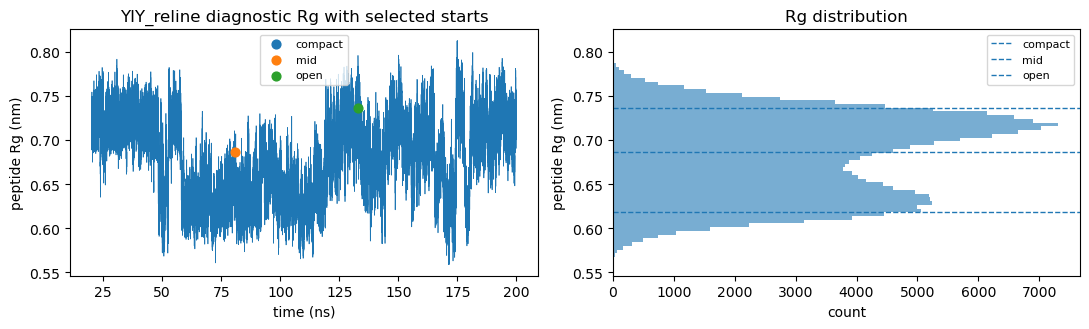

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
ax1.plot(t_eq, rg_eq, lw=0.5)
for label, gidx in zip([l for l, _ in SELECTIONS], sel_global):
    ax1.scatter(gidx * dt_ps / 1000.0, rg_all[gidx], s=40, zorder=5, label=label)
ax1.set_xlabel("time (ns)"); ax1.set_ylabel("peptide Rg (nm)")
ax1.set_title(f"{SYSTEM} diagnostic Rg with selected starts"); ax1.legend(fontsize=8)

ax2.hist(rg_eq, bins=60, orientation="horizontal", alpha=0.6)
for label, gidx in zip([l for l, _ in SELECTIONS], sel_global):
    ax2.axhline(rg_all[gidx], lw=1.0, ls="--", label=label)
ax2.set_ylabel("peptide Rg (nm)"); ax2.set_xlabel("count")
ax2.set_title("Rg distribution"); ax2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / f"{SYSTEM}_start_selection.png", dpi=150)
plt.show()

## 8 — E2.1 configuration blocks
Paste one block into the E2.1 config cell per diverse-start replicate. The extended-start r1 is
already done; these are the compact/mid/extended runs that complete the convergence set.
**Out:** printed configs.

In [9]:
print("# --- paste into E2_1_Extended_Production.ipynb config cell (cell 3) ---\n")
for label in [l for l, _ in SELECTIONS]:
    print(f'SYSTEM          = "{SYSTEM}"')
    print(f'NS              = {NS_TARGET}')
    print(f'START           = "{label}"')
    print(f'REP             = 1')
    print(f'PLATFORM        = "OpenCL"')
    print(f'START_STRUCTURE = "{paths[label]}"')
    print()

# --- paste into E2_1_Extended_Production.ipynb config cell (cell 3) ---

SYSTEM          = "YIY_reline"
NS              = 200
START           = "compact"
REP             = 1
PLATFORM        = "OpenCL"
START_STRUCTURE = "/Users/rossgibson/des-peptide-study/extension/start_frames/YIY_reline/YIY_reline_compact.pdb"

SYSTEM          = "YIY_reline"
NS              = 200
START           = "mid"
REP             = 1
PLATFORM        = "OpenCL"
START_STRUCTURE = "/Users/rossgibson/des-peptide-study/extension/start_frames/YIY_reline/YIY_reline_mid.pdb"

SYSTEM          = "YIY_reline"
NS              = 200
START           = "open"
REP             = 1
PLATFORM        = "OpenCL"
START_STRUCTURE = "/Users/rossgibson/des-peptide-study/extension/start_frames/YIY_reline/YIY_reline_open.pdb"

